# 1D-CNN 기반 네트워크 침입 탐지 (v4 - SSAE + DeepCNN 하이브리드)

- **SSAE (Stacked Sparse Autoencoder) 사전 학습**: L1 제약(1e-3)을 이용해 70개 Feature 중 노이즈를 걸러내고 중요한 특징 64개를 추출하는 비지도 학습
- **DeepCNN 지도 학습**: 4개의 CNN+1D 블록(Conv1D x2 + MaxPool + BatchNorm + Dropout)을 통과하는 심층망으로 분류
- **Loss**: 단계 2에 한해 (v3)에서 효과를 본 온건한 `class_weight` + `CrossEntropyLoss` 적용
- 체크포인트: `checkpoint_ssae_v4.pt` / `best_model_v4.pt`

## 1. 라이브러리 임포트

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 재현성 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.11.0+cu126
Device          : cuda


## 2. 데이터 로드

In [2]:
BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
OUTPUT_DIR = os.path.join(BASE_DIR, "processed")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X = np.load(os.path.join(OUTPUT_DIR, "X.npy"))
y = np.load(os.path.join(OUTPUT_DIR, "y.npy"))

with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = json.load(f)

idx2label   = {v: k for k, v in label_mapping.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]
num_classes = len(class_names)

# Train 70 / Val 15 / Test 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

## 3. Dataset & DataLoader (1D Vector 형태)

In [5]:
class IDSDataset_Vector(Dataset):
    def __init__(self, X, y):
        # SSAE에 넣기 위해 (Batch, Seq) 차원을 유지. (1D CNN은 나중에 차원 재배열)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 512

train_loader = DataLoader(IDSDataset_Vector(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(IDSDataset_Vector(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(IDSDataset_Vector(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 4. SSAE (Stacked Sparse Autoencoder) 사전 학습

In [6]:
# --- SSAE 모델 정의 ---
class SSAE(nn.Module):
    def __init__(self, input_dim=70, hidden_dim=64):
        super().__init__()
        # Encoder: 70 -> 128 -> 64
        self.enc1 = nn.Linear(input_dim, 128)
        self.enc2 = nn.Linear(128, hidden_dim)
        
        # Decoder: 64 -> 128 -> 70
        self.dec1 = nn.Linear(hidden_dim, 128)
        self.dec2 = nn.Linear(128, input_dim)
        
    def encode(self, x):
        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(e1))
        return e2, e1 # L1 페널티를 위해 활성화 값 반환
        
    def forward(self, x):
        e2, e1 = self.encode(x)
        d1 = torch.relu(self.dec1(e2))
        out = torch.sigmoid(self.dec2(d1)) # 데이터가 Min-Max 정규화(0~1)되어 있으므로 Sigmoid 사용
        return out, e2, e1

ssae = SSAE(input_dim=X_train.shape[1], hidden_dim=64).to(DEVICE)
ssae_criterion = nn.MSELoss()
ssae_optimizer = optim.Adam(ssae.parameters(), lr=1e-3)

# L1 희소성 계수 = 1e-3
L1_LAMBDA = 1e-3
SSAE_EPOCHS = 20

print("=== 비지도 학습: SSAE (특징 중요도 추출 및 노이즈 제거) ===")
ssae.train()
for epoch in range(1, SSAE_EPOCHS + 1):
    total_loss = 0.0
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(DEVICE)
        
        out, e2, e1 = ssae(X_batch)
        
        # MSE + L1 희소성 제약
        mse_loss = ssae_criterion(out, X_batch)
        l1_loss  = e1.abs().mean() + e2.abs().mean()
        
        loss = mse_loss + L1_LAMBDA * l1_loss
        
        ssae_optimizer.zero_grad()
        loss.backward()
        ssae_optimizer.step()
        
        total_loss += loss.item() * len(X_batch)
        
    print(f"SSAE Epoch {epoch:02d}/{SSAE_EPOCHS} | Loss: {total_loss/len(train_loader.dataset):.6f}")

torch.save(ssae.state_dict(), os.path.join(MODEL_DIR, "ssae_pretrained.pt"))
print("SSAE 사전 학습 완료 및 가중치 저장됨.\n")

=== 비지도 학습: SSAE (특징 중요도 추출 및 노이즈 제거) ===
SSAE Epoch 01/20 | Loss: 0.678795
SSAE Epoch 02/20 | Loss: 0.666928
SSAE Epoch 03/20 | Loss: 0.666271
SSAE Epoch 04/20 | Loss: 0.665928
SSAE Epoch 05/20 | Loss: 0.665716
SSAE Epoch 06/20 | Loss: 0.665564
SSAE Epoch 07/20 | Loss: 0.665505
SSAE Epoch 08/20 | Loss: 0.665488
SSAE Epoch 09/20 | Loss: 0.665511
SSAE Epoch 10/20 | Loss: 0.665427
SSAE Epoch 11/20 | Loss: 0.665289
SSAE Epoch 12/20 | Loss: 0.665287
SSAE Epoch 13/20 | Loss: 0.665265
SSAE Epoch 14/20 | Loss: 0.665266
SSAE Epoch 15/20 | Loss: 0.665252
SSAE Epoch 16/20 | Loss: 0.665248
SSAE Epoch 17/20 | Loss: 0.665237
SSAE Epoch 18/20 | Loss: 0.665235
SSAE Epoch 19/20 | Loss: 0.665217
SSAE Epoch 20/20 | Loss: 0.665226
SSAE 사전 학습 완료 및 가중치 저장됨.



## 5. 특징 추출 확인 및 DeepCNN 설계

- SSAE의 Encoder 부분을 통과하면 70개의 Feature가 핵심 내용만 담긴 64크기의 벡터로 압축됨.
- 이 64 크기의 벡터를 `(batch_size, 1, 64)`의 형태로 reshape하여 1D CNN에 넣기.
- DeepCNN은 **2x Conv1d + MaxPool + BatchNorm + Dropout** 의 블록 4개로 구성됨.

In [7]:
class SSAE_DeepCNN(nn.Module):
    def __init__(self, encoder, num_classes=7):
        super().__init__()
        # 사전 학습된 인코더 활용
        self.encoder = encoder
        
        def make_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.BatchNorm1d(out_ch),
                nn.Dropout(0.3)
            )
            
        # Input Sequence Length: 64
        self.cnn = nn.Sequential(
            make_block(1, 32),   # 64 -> 32 len
            make_block(32, 64),  # 32 -> 16 len
            make_block(64, 128), # 16 -> 8 len
            make_block(128, 256) # 8 -> 4 len
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # SSAE를 통한 중요도 특징 추출
        e2, _ = self.encoder.encode(x) # (B, 64)
        
        # 1D CNN을 위한 차원 추가
        out = e2.unsqueeze(1) # (B, 1, 64)
        
        # 4-Block DeepCNN
        out = self.cnn(out)
        out = self.classifier(out)
        return out

model = SSAE_DeepCNN(encoder=ssae, num_classes=num_classes).to(DEVICE)
print(f"총 파라미터 수 (Feature Extracter 포함): {sum(p.numel() for p in model.parameters()):,}")

총 파라미터 수 (Feature Extracter 포함): 1,018,221


## 6. 모델 학습 (분류기)

In [8]:
# v3에서 사용한 온건한 class_weight 가져오기
train_counts = torch.zeros(num_classes)
for i in range(num_classes):
    train_counts[i] = (torch.tensor(y_train) == i).sum()

median_count = train_counts.median()
weights = torch.clamp(median_count / train_counts, min=1.0, max=3.0).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

EPOCHS = 50
PATIENCE = 7
BEST_PATH = os.path.join(MODEL_DIR, "best_model_v4.pt")

best_val_loss = float("inf")
patience_cnt = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total

print("\n=== 지도 학습: DeepCNN (특징 벡터 이용 상태 분류) ===")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    
    scheduler.step(vl_loss)
    
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    marker = " ★" if vl_loss < best_val_loss else ""
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), BEST_PATH)
    else:
        patience_cnt += 1
        
    print(f"Epoch {epoch:02d}/{EPOCHS}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}{marker}")
    
    if patience_cnt >= PATIENCE:
        print(f"\nEarly Stopping (patience={PATIENCE})")
        break



=== 지도 학습: DeepCNN (특징 벡터 이용 상태 분류) ===
Epoch 01/50  train_loss=0.2595 train_acc=0.8932 val_loss=0.2407 val_acc=0.9028 ★
Epoch 02/50  train_loss=0.2440 train_acc=0.9000 val_loss=0.2408 val_acc=0.9027
Epoch 03/50  train_loss=0.2422 train_acc=0.9015 val_loss=0.2392 val_acc=0.9067 ★
Epoch 04/50  train_loss=0.2398 train_acc=0.9026 val_loss=0.2393 val_acc=0.9077
Epoch 05/50  train_loss=0.2384 train_acc=0.9038 val_loss=0.2358 val_acc=0.9067 ★
Epoch 06/50  train_loss=0.2369 train_acc=0.9041 val_loss=0.2340 val_acc=0.9064 ★
Epoch 07/50  train_loss=0.2359 train_acc=0.9042 val_loss=0.2332 val_acc=0.9073 ★
Epoch 08/50  train_loss=0.2348 train_acc=0.9041 val_loss=0.2355 val_acc=0.9026
Epoch 09/50  train_loss=0.2340 train_acc=0.9039 val_loss=0.2325 val_acc=0.9059 ★
Epoch 10/50  train_loss=0.2336 train_acc=0.9044 val_loss=0.2316 val_acc=0.9063 ★
Epoch 11/50  train_loss=0.2330 train_acc=0.9039 val_loss=0.2303 val_acc=0.9082 ★
Epoch 12/50  train_loss=0.2326 train_acc=0.9038 val_loss=0.2296 val_acc=0.

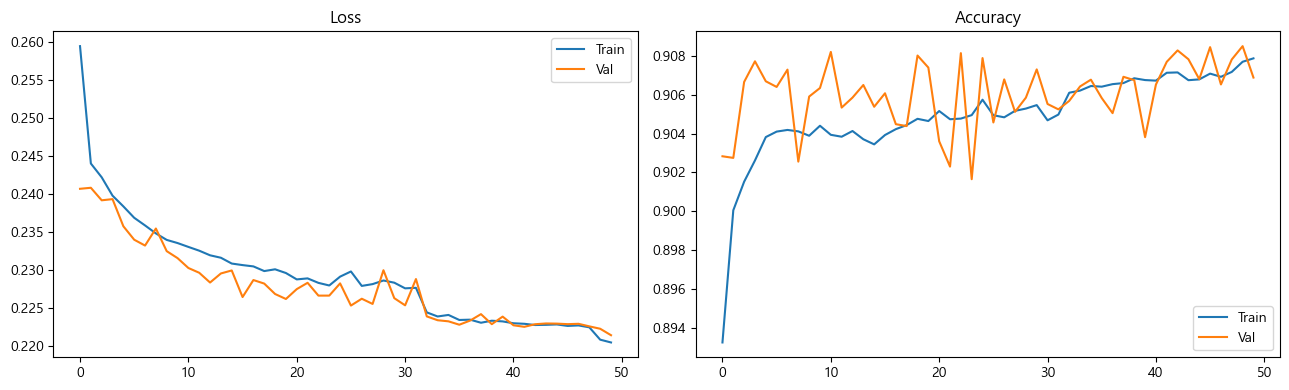

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")

for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## 7. 성능 평가

In [10]:
BEST_PATH = os.path.join(MODEL_DIR, "best_model_v4.pt")

model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("=== Classification Report (v4: SSAE + DeepCNN 하이브리드) ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

=== Classification Report (v4: SSAE + DeepCNN 하이브리드) ===
               precision    recall  f1-score   support

       Benign     0.8419    0.8758    0.8585     75000
          Bot     0.9999    0.9999    0.9999     42929
  Brute Force     0.8645    0.9538    0.9070     57269
         DDoS     0.9994    0.9999    0.9996     75000
          DoS     0.9627    0.8859    0.9227     75000
 Infiltration     0.5641    0.4947    0.5271     24290
SQL Injection     0.8067    0.8067    0.8067       150

     accuracy                         0.9061    349638
    macro avg     0.8627    0.8595    0.8602    349638
 weighted avg     0.9054    0.9061    0.9048    349638



## 8. 모델 메타데이터 저장

In [11]:
meta = {
    "version"        : "v4",
    "loss"           : "CrossEntropyLoss (class_weight) / L1 제약",
    "architecture"   : "SSAE (Encoder) + DeepCNN (4-Block 1D-CNN)",
    "num_features"   : X_train.shape[1],
    "num_classes"    : num_classes,
    "class_names"    : class_names,
    "best_val_loss"  : round(best_val_loss, 6),
}
with open(os.path.join(MODEL_DIR, "model_meta_v4.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("v4 메타데이터 저장 완료!")

v4 메타데이터 저장 완료!
